# DocuMind: Measurable RAG Experiment

This notebook stays in the experimental phase. We build a reproducible baseline, add a Cross-Encoder reranker, and compare both systems on a small golden set. Python owns retrieval metadata and citations; the LLM only drafts an answer from supplied context.

## 1. Setup

Run the installation cell once in the notebook environment. Restarting the kernel clears Python variables, but the persistent Qdrant collection remains on disk and is reopened by one client later.

## 2. What We Are Learning

**Embeddings:** an embedding model maps text to vectors so semantically related text can be nearby. It is local and free here. Embedding similarity is useful for candidate retrieval, but it does not prove that a question is answerable.

**Chunking:** chunks are the units Qdrant retrieves. Small chunks are precise but may lose context; large chunks preserve context but can dilute the relevant passage. The 300/500/800/1200 experiment measures size and count only. The golden set must decide retrieval quality.

**Qdrant:** Qdrant stores chunk vectors and metadata. `RESET_QDRANT = True` rebuilds the collection from the current notebook chunks, while `False` explicitly reuses an existing collection. One active local client owns the storage path.

**Generation and citations:** the prompt contains only retrieved sources. Python formats source numbers, filenames, and pages from metadata. The LLM cannot invent those citation fields.

**Cross-Encoder reranking:** Qdrant first retrieves candidates using vector similarity. The Cross-Encoder then scores each `(query, document)` pair jointly, which is slower but often more precise. Scores are ranking signals, not percentages. The optional page limit exposes the diversity tradeoff when several chunks from one page dominate.

**Evaluation:** the same golden questions run through Qdrant-only and Qdrant-plus-reranker. Page Recall@5 is only a first page-level diagnostic; later context-level evaluation will be more meaningful. Ragas belongs after this baseline is stable.

In [ ]:
%pip install -q pypdf langchain-community langchain-text-splitters langchain-huggingface langchain-qdrant qdrant-client sentence-transformers scikit-learn pandas matplotlib langchain-ollama

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from pathlib import Path
from typing import Any
import shutil
import time

import pandas as pd
from langchain_community.document_loaders import PyPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams
from langchain_qdrant import QdrantVectorStore
from sentence_transformers import CrossEncoder, SentenceTransformer

try:
    from langchain_ollama import ChatOllama
except ImportError:
    ChatOllama = None

C:\Users\Shashwat\AppData\Local\Temp\ipykernel_16372\32985994.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
c:\Users\Shashwat\OneDrive\Desktop\DocuMind\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASELINE_CONFIG = {
    "chunk_size": 800,
    "chunk_overlap": 150,
    "retrieval_top_k": 10,
    "reranker_enabled": True,
    "reranker_top_k": 5,
    "max_chunks_per_page": 2,
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "reranker_model": "cross-encoder/ms-marco-MiniLM-L-6-v2",
}
EXPERIMENT_CONFIG = BASELINE_CONFIG.copy()
EXPERIMENT_RESULTS = []
EXPERIMENT_DETAILS = {}

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "documents"
QDRANT_PATH = PROJECT_ROOT / "qdrant_storage"
COLLECTION_NAME = "documind"
RESET_QDRANT = True  # Reset for reproducible experiments; set False only to reuse a known collection.
EMBEDDING_MODEL_NAME = BASELINE_CONFIG["embedding_model"]
RERANKER_MODEL_NAME = BASELINE_CONFIG["reranker_model"]
CHUNK_SIZE = EXPERIMENT_CONFIG["chunk_size"]
CHUNK_OVERLAP = EXPERIMENT_CONFIG["chunk_overlap"]
RUN_LLM_EVALUATION = False  # Set True only when Ollama is running with llama3.2:3b.
UNKNOWN_ANSWER = "I don't know based on the provided documents."

pdf_files = sorted(DATA_DIR.glob("*.pdf"))
if not pdf_files:
    raise FileNotFoundError(f"No PDF files found in {DATA_DIR}")
PDF_PATH = pdf_files[0]
print(f"Using document: {PDF_PATH.name}")
print(f"Baseline configuration: {BASELINE_CONFIG}")

Using document: Shashwat_AI_ML_Project_Roadmap.pdf
Baseline configuration: {'chunk_size': 800, 'chunk_overlap': 150, 'retrieval_top_k': 10, 'reranker_enabled': True, 'reranker_top_k': 5, 'max_chunks_per_page': 2, 'embedding_model': 'sentence-transformers/all-MiniLM-L6-v2', 'reranker_model': 'cross-encoder/ms-marco-MiniLM-L-6-v2'}


In [3]:
loader = PyPDFLoader(str(PDF_PATH))
documents = loader.load()

print(f"Pages loaded: {len(documents)}")
print(f"First page metadata: {documents[0].metadata}")
print(documents[0].page_content[:1000])

Pages loaded: 10
First page metadata: {'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-08-17T17:32:18+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-08-17T17:32:18+00:00', 'subject': '(unspecified)', 'title': 'Shashwat - Applied AI/ML Engineering Roadmap', 'trapped': '/False', 'source': 'c:\\Users\\Shashwat\\OneDrive\\Desktop\\DocuMind\\data\\documents\\Shashwat_AI_ML_Project_Roadmap.pdf', 'total_pages': 10, 'page': 0, 'page_label': '1'}
Shashwat — Applied AI/ML Engineering
Project Portfolio, DSA & System Design Prep Roadmap
1. Where To Focus: Career Direction
Given a strong base in Python and classic ML (regression/classification, Scikit-learn), backend fundamentals
(Node/Express, REST APIs, MySQL/MongoDB), and early exposure to MLOps (MLflow, Docker, Flask), Applied
AI/ML Engineering is the right lane — not a deep-research ML Scientist track. This role is about building and
shipping AI-powered systems (RAG, agen

## 3. Document Loading

The loader creates one page-level `Document` at a time. Page metadata is zero-based internally, so citation formatting converts it to the human-facing page number.

In [5]:
print("Document loading output is above.")

Document loading output is above.


## 4. Chunking Experiments

Chunks balance precision and context. The count table is descriptive only; retrieval quality will be decided by the golden set, not by choosing the most convenient chunk count.

In [4]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""]
)
chunks = splitter.split_documents(documents)
print(f"Baseline chunks: {len(chunks)} | size={CHUNK_SIZE} | overlap={CHUNK_OVERLAP}")

Baseline chunks: 41 | size=800 | overlap=150


In [7]:
chunk_sizes = [300, 500, 800, 1200]
chunking_experiment = []

for size in chunk_sizes:
    experiment_splitter = RecursiveCharacterTextSplitter(
        chunk_size=size,
        chunk_overlap=min(100, size // 5)
    )
    experiment_chunks = experiment_splitter.split_documents(documents)
    chunking_experiment.append({
        "chunk_size": size,
        "chunk_overlap": min(100, size // 5),
        "number_of_chunks": len(experiment_chunks),
    })

chunking_experiment_df = pd.DataFrame(chunking_experiment)
chunking_experiment_df

,chunk_size,chunk_overlap,number_of_chunks
0,300,60,105
1,500,100,62
2,800,100,37
3,1200,100,27


In [5]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
example_vectors = embedding_model.encode(
    ["Machine learning learns patterns from data.", "The library closes at 8 PM."],
    normalize_embeddings=True,
)
print(f"Embedding shape: {example_vectors.shape}")
print("Chunk size affects how much evidence fits in one retrieved unit; retrieval quality must be measured on the golden set.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3046.85it/s]


Embedding shape: (2, 384)
Chunk size affects how much evidence fits in one retrieved unit; retrieval quality must be measured on the golden set.


## 5. Embedding Model

The local sentence-transformer converts queries and chunks into 384-dimensional vectors. Similarity finds candidates; it does not establish answerability.

In [6]:
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)
print("Using the maintained langchain_huggingface integration with a local embedding model.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2951.43it/s]


Using the maintained langchain_huggingface integration with a local embedding model.


In [8]:
# Close a stale client restored in this same notebook kernel before opening the one active client.
for stale_name in ("qdrant_client", "vector_store"):
    stale_object = globals().get(stale_name)
    stale_client = getattr(stale_object, "client", stale_object)
    if stale_client is not None and hasattr(stale_client, "close"):
        stale_client.close()

qdrant_client = QdrantClient(path=str(QDRANT_PATH))
collection_exists = qdrant_client.collection_exists(COLLECTION_NAME)

if RESET_QDRANT:
    if collection_exists:
        qdrant_client.delete_collection(COLLECTION_NAME)
    qdrant_client.close()
    if QDRANT_PATH.exists():
        shutil.rmtree(QDRANT_PATH)
    QDRANT_PATH.mkdir(parents=True, exist_ok=True)
    qdrant_client = QdrantClient(path=str(QDRANT_PATH))
    collection_exists = False
    print("Qdrant collection reset.")

if collection_exists:
    vector_store = QdrantVectorStore(
        client=qdrant_client,
        collection_name=COLLECTION_NAME,
        embedding=embeddings,
    )
    print("Using existing Qdrant collection.")
else:
    embedding_dimension = len(embeddings.embed_query("dimension probe"))
    qdrant_client.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config=VectorParams(size=embedding_dimension, distance=Distance.COSINE),
    )
    vector_store = QdrantVectorStore(
        client=qdrant_client,
        collection_name=COLLECTION_NAME,
        embedding=embeddings,
    )
    vector_store.add_documents(chunks)
    print("Created Qdrant collection from current notebook chunks.")

indexed_count = qdrant_client.count(collection_name=COLLECTION_NAME).count
if RESET_QDRANT and indexed_count != len(chunks):
    raise RuntimeError(f"Expected {len(chunks)} indexed chunks after reset, found {indexed_count}.")
print(f"Indexed {indexed_count} chunks.")

Qdrant collection reset.
Created Qdrant collection from current notebook chunks.
Indexed 41 chunks.


## 6. Qdrant Setup

Qdrant stores vectors plus document metadata. One local client owns the persistent path; after a kernel restart the collection is reopened instead of recreated or deleted.

In [9]:
def _page_number(document: Any) -> int | None:
    page = document.metadata.get("page")
    return page + 1 if isinstance(page, int) else None


def _source_name(document: Any) -> str:
    source = document.metadata.get("source", PDF_PATH.name)
    return Path(str(source)).name


def retrieve_documents(query: str, k: int = 5) -> list[dict[str, Any]]:
    """Return Qdrant results with stable names and scores."""
    raw_results = vector_store.similarity_search_with_score(query, k=k)
    return [
        {"document": document, "retrieval_score": float(score)}
        for document, score in raw_results
    ]


def build_context(results: list[dict[str, Any]]) -> str:
    """Format evidence with Python-owned source and page labels."""
    context_parts = []
    for source_number, result in enumerate(results, start=1):
        document = result["document"]
        page = _page_number(document)
        page_label = str(page) if page is not None else "unknown"
        context_parts.append(
            f"[SOURCE {source_number} | Page {page_label}]\n{document.page_content}"
        )
    return "\n\n".join(context_parts)


def source_metadata(results: list[dict[str, Any]]) -> list[dict[str, Any]]:
    return [
        {
            "source": _source_name(result["document"]),
            "page": _page_number(result["document"]),
            "score": result.get("reranker_score", result["retrieval_score"]),
        }
        for result in results
    ]

## 7. Baseline Retrieval

The baseline is intentionally simple: query embedding, Qdrant similarity search, and top-k chunks. The helper returns named records so later experiments do not overwrite unrelated variables.

In [14]:
baseline_query = "What technologies are listed for Project 1?"
retrieved_results = retrieve_documents(baseline_query, k=5)
print(build_context(retrieved_results))
print("\nPython-owned citations:")
print(source_metadata(retrieved_results))

[SOURCE 1 | Page 8]
3. Trending AI Engineering Concepts Worth Knowing
Beyond what's built into the projects above, these are the concepts coming up most often in AI Engineer interviews
and job descriptions right now. He doesn't need to build all of them — but should be able to explain each one in a
sentence or two, and Project 6 already gives him hands-on MCP experience to speak from.
MCP (Model Context Protocol) — An open standard (introduced by Anthropic) for connecting AI models/agents to
external tools and data sources through a single common interface, instead of every app writing its own custom
tool-calling glue code. Project 6 above is built specifically to give him real, demoable experience with it.

[SOURCE 2 | Page 10]

Model monitoring & drift detection design — what to log, what triggers a retrain

Designing an agentic system with guardrails — tool-use safety, loop limits, human-in-the-loop escalation
(directly reusable from Projects 2 & 5 above)

A/B testing design for 

## 8. Context Construction and Citations

The context includes source numbers and safe page labels. Citation metadata comes from retrieved `Document` objects in Python, so the model is not trusted to invent filenames or pages.

In [10]:
reranker = CrossEncoder(RERANKER_MODEL_NAME)
print("Cross-Encoder loaded. Its scores are ranking signals, not percentages or probabilities.")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 2785.71it/s]


Cross-Encoder loaded. Its scores are ranking signals, not percentages or probabilities.


In [11]:
def rerank_documents(
    query: str,
    k_retrieve: int = 10,
    k_final: int = 5,
    max_per_page: int | None = 2,
) -> list[dict[str, Any]]:
    """Retrieve candidates, score (query, document) pairs, then optionally diversify pages."""
    candidates = retrieve_documents(query, k=k_retrieve)
    pairs = [(query, result["document"].page_content) for result in candidates]
    rerank_scores = reranker.predict(pairs)

    scored_results = []
    for result, score in zip(candidates, rerank_scores):
        scored_results.append({**result, "reranker_score": float(score)})
    scored_results.sort(key=lambda result: result["reranker_score"], reverse=True)

    if max_per_page is None:
        return scored_results[:k_final]

    diversified_results = []
    page_counts = {}
    for result in scored_results:
        page_key = result["document"].metadata.get("page", "unknown")
        if page_counts.get(page_key, 0) >= max_per_page:
            continue
        diversified_results.append(result)
        page_counts[page_key] = page_counts.get(page_key, 0) + 1
        if len(diversified_results) == k_final:
            break
    return diversified_results

## 9. LLM Generation

Generation is source-constrained and disabled by default for repeatable retrieval experiments. Set `RUN_LLM_EVALUATION = True` only when the local Ollama model is available.

In [15]:
reranked_results = rerank_documents(baseline_query, k_retrieve=10, k_final=5)
for rank, result in enumerate(reranked_results, start=1):
    document = result["document"]
    print(
        f"{rank}. page={_page_number(document)} "
        f"qdrant={result['retrieval_score']:.4f} "
        f"reranker={result['reranker_score']:.4f}"
    )

1. page=1 qdrant=0.3829 reranker=-2.6749
2. page=10 qdrant=0.3921 reranker=-3.1099
3. page=7 qdrant=0.3725 reranker=-4.1713
4. page=1 qdrant=0.3581 reranker=-5.1156
5. page=7 qdrant=0.3419 reranker=-6.0620


In [12]:
def make_prompt(query: str, results: list[dict[str, Any]]) -> str:
    return f"""You are a document question-answering assistant.

Use ONLY the provided sources. Do not use outside knowledge or invent citations.
If the answer is not supported, say exactly: {UNKNOWN_ANSWER}
Keep the answer concise and cite source numbers such as [SOURCE 1].

Sources:
{build_context(results)}

Question: {query}
Answer:"""


def generate_answer(query: str, results: list[dict[str, Any]]) -> str:
    if llm is None:
        return "LLM disabled; inspect the retrieved context and citations instead."
    return llm.invoke(make_prompt(query, results)).content

## 10. Cross-Encoder Reranker

The reranker sees each query and candidate together. It can reorder the top 10 candidates more precisely than independent vector representations, but it is slower and does not guarantee improvement.

In [16]:
llm = None
if RUN_LLM_EVALUATION and ChatOllama is not None:
    llm = ChatOllama(model="llama3.2:3b", temperature=0)
print("LLM generation:", "enabled" if llm is not None else "disabled (retrieval-only Run All)")

answer = generate_answer(baseline_query, reranked_results)
print(answer)
print("\nSources:")
print(source_metadata(reranked_results))

LLM generation: disabled (retrieval-only Run All)
LLM disabled; inspect the retrieved context and citations instead.

Sources:
[{'source': 'Shashwat_AI_ML_Project_Roadmap.pdf', 'page': 1, 'score': -2.6749205589294434}, {'source': 'Shashwat_AI_ML_Project_Roadmap.pdf', 'page': 10, 'score': -3.1098690032958984}, {'source': 'Shashwat_AI_ML_Project_Roadmap.pdf', 'page': 7, 'score': -4.171338081359863}, {'source': 'Shashwat_AI_ML_Project_Roadmap.pdf', 'page': 1, 'score': -5.115560531616211}, {'source': 'Shashwat_AI_ML_Project_Roadmap.pdf', 'page': 7, 'score': -6.062009811401367}]


In [17]:
golden_set = [
    {"question": "What career direction does the roadmap recommend?", "ground_truth": "Applied AI/ML Engineering rather than a deep-research ML Scientist track.", "source_pages": [1], "type": "factual"},
    {"question": "What technologies are listed for Project 1, DocuMind?", "ground_truth": "FastAPI, LangChain or LlamaIndex, Qdrant or ChromaDB, sentence-transformers, Redis, Ragas, Langfuse, Docker, and GitHub Actions.", "source_pages": [1], "type": "multi_context"},
    {"question": "What is the ingestion pipeline order for DocuMind?", "ground_truth": "PDF/text loader, chunking, embeddings, then vector store.", "source_pages": [1], "type": "factual"},
    {"question": "What retrieval stages are proposed before the LLM in DocuMind?", "ground_truth": "Similarity search followed by a lightweight Cross-Encoder reranker, then the context is passed to the LLM.", "source_pages": [1], "type": "factual"},
    {"question": "Which Ragas metrics are named for the DocuMind golden set?", "ground_truth": "Faithfulness, answer relevancy, context precision, and context recall.", "source_pages": [1], "type": "factual"},
    {"question": "What nodes are in the Project 2 LangGraph agent?", "ground_truth": "Planner, Researcher, Writer, and Critic.", "source_pages": [2], "type": "factual"},
    {"question": "What observability technologies are proposed for Project 2?", "ground_truth": "OpenTelemetry and Langfuse, with cost and latency shown per node.", "source_pages": [2], "type": "multi_context"},
    {"question": "Why does the roadmap suggest hybrid search?", "ground_truth": "Pure vector search can miss exact-match terms such as product codes or names.", "source_pages": [2], "type": "factual"},
    {"question": "What is planned for weeks 1 and 2 of the roadmap?", "ground_truth": "Project 1, DocuMind RAG API, plus DSA topics: Arrays, Hashing, Two Pointers, and Binary Search.", "source_pages": [10], "type": "multi_context"},
    {"question": "What is the population of Mars according to this document?", "ground_truth": UNKNOWN_ANSWER, "source_pages": [], "type": "unanswerable"},
]
print(f"Golden questions: {len(golden_set)}")

Golden questions: 10


## 11. Golden Evaluation Set

These questions are grounded in the uploaded roadmap. The set mixes direct facts, section-specific questions, multi-part questions, and one deliberately unanswerable question.

In [18]:
def evaluate_configuration(question_record: dict[str, Any], use_reranker: bool) -> dict[str, Any]:
    question = question_record["question"]
    if use_reranker:
        final_results = rerank_documents(question, k_retrieve=10, k_final=5)
    else:
        final_results = retrieve_documents(question, k=5)
    pages = [_page_number(result["document"]) for result in final_results]
    return {
        "question": question,
        "type": question_record["type"],
        "expected_source_pages": question_record["source_pages"],
        "retrieved_pages": pages,
        "answer": generate_answer(question, final_results) if RUN_LLM_EVALUATION else None,
        "sources": source_metadata(final_results),
    }

baseline_evaluation = [evaluate_configuration(record, use_reranker=False) for record in golden_set]
reranker_evaluation = [evaluate_configuration(record, use_reranker=True) for record in golden_set]

comparison_rows = []
for baseline_row, reranker_row in zip(baseline_evaluation, reranker_evaluation):
    comparison_rows.append({
        "question": baseline_row["question"],
        "type": baseline_row["type"],
        "expected_source_pages": baseline_row["expected_source_pages"],
        "baseline_retrieved_pages": baseline_row["retrieved_pages"],
        "reranked_pages": reranker_row["retrieved_pages"],
        "baseline_answer": baseline_row["answer"],
        "reranked_answer": reranker_row["answer"],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df[["question", "type", "expected_source_pages", "baseline_retrieved_pages", "reranked_pages"]]

,question,type,expected_source_pages,baseline_retrieved_pages,reranked_pages
0,What career direction does the roadmap recommend?,factual,[1],"[1, 10, 10, 8, 9]","[1, 10, 10, 7, 2]"
1,"What technologies are listed for Project 1, Do...",multi_context,[1],"[8, 1, 10, 7, 8]","[1, 10, 10, 7, 1]"
2,What is the ingestion pipeline order for DocuM...,factual,[1],"[1, 4, 2, 1, 10]","[1, 1, 10, 10, 6]"
3,What retrieval stages are proposed before the ...,factual,[1],"[1, 9, 7, 5, 8]","[1, 8, 9, 2, 5]"
4,Which Ragas metrics are named for the DocuMind...,factual,[1],"[2, 1, 1, 2, 7]","[2, 1, 2, 5, 10]"
5,What nodes are in the Project 2 LangGraph agent?,factual,[2],"[2, 3, 8, 6, 2]","[2, 6, 3, 2, 10]"
6,What observability technologies are proposed f...,multi_context,[2],"[10, 8, 7, 6, 8]","[7, 6, 10, 7, 8]"
7,Why does the roadmap suggest hybrid search?,factual,[2],"[9, 2, 9, 10, 2]","[10, 2, 10, 1, 9]"
8,What is planned for weeks 1 and 2 of the roadmap?,multi_context,[10],"[10, 10, 10, 7, 6]","[10, 10, 7, 9, 6]"
9,What is the population of Mars according to th...,unanswerable,[],"[1, 4, 4, 2, 4]","[5, 4, 4, 7, 2]"


## 12. Baseline vs. Reranker Experiment

Both systems receive the same questions. We record retrieved pages and optional answers in a table so improvements or regressions can be measured rather than inferred from one demo.

In [19]:
def page_recall_at_5(retrieved_pages: list[int | None], expected_pages: list[int]) -> bool:
    """Initial diagnostic: did any of the top-five chunks come from an expected page?"""
    return bool(expected_pages) and any(page in expected_pages for page in retrieved_pages[:5])


answerable_mask = comparison_df["expected_source_pages"].map(bool)
comparison_df["baseline_page_recall_at_5"] = comparison_df.apply(
    lambda row: page_recall_at_5(row["baseline_retrieved_pages"], row["expected_source_pages"]),
    axis=1,
)
comparison_df["reranker_page_recall_at_5"] = comparison_df.apply(
    lambda row: page_recall_at_5(row["reranked_pages"], row["expected_source_pages"]),
    axis=1,
)

baseline_page_recall = comparison_df.loc[answerable_mask, "baseline_page_recall_at_5"].mean()
reranker_page_recall = comparison_df.loc[answerable_mask, "reranker_page_recall_at_5"].mean()
improvement = reranker_page_recall - baseline_page_recall

print("=" * 50)
print("BASELINE VS RERANKER")
print("=" * 50)
print(f"Number of chunks: {len(chunks)}")
print(f"Qdrant collection: {COLLECTION_NAME} | indexed={indexed_count} | reset={RESET_QDRANT}")
print(f"Baseline Page Recall@5: {baseline_page_recall:.2f}")
print(f"Reranker Page Recall@5: {reranker_page_recall:.2f}")
print(f"Improvement: {improvement:+.2f}")
print("\nUnanswerable test retrieved pages:")
print(comparison_df.loc[comparison_df["type"] == "unanswerable", ["question", "baseline_retrieved_pages", "reranked_pages"]].to_string(index=False))

BASELINE VS RERANKER
Number of chunks: 41
Qdrant collection: documind | indexed=41 | reset=True
Baseline Page Recall@5: 0.89
Reranker Page Recall@5: 0.89
Improvement: +0.00

Unanswerable test retrieved pages:
                                                  question baseline_retrieved_pages  reranked_pages
What is the population of Mars according to this document?          [1, 4, 4, 2, 4] [5, 4, 4, 7, 2]


## 13. Results and Observations

**Page Recall@5** asks whether at least one of the top-five retrieved chunks comes from an expected source page. It is only an initial diagnostic: a correct page does not guarantee that the retrieved chunk contains the answer. Later context-level evaluation, including Ragas, will be more meaningful.

The unanswerable question is reported separately because recall is undefined when no source page is expected. Similarity is not answerability: Qdrant still returns its closest chunks for an unrelated question. We do not add an arbitrary score threshold without evidence from a larger evaluation set.

## 14. Controlled Experiment Plan

Every experiment changes one factor, runs the same golden set, uses the same Page Recall@5 and MRR calculations, and records latency and context size. The priority order is: (1) chunk size and overlap, (2) retrieval top-k, (3) reranker on/off and depth, (4) page diversification, (5) a small local embedding-model comparison. Hybrid search, query rewriting, HyDE, prompt variants, and Ragas require additional infrastructure and are intentionally deferred.

The first run below is the cheapest high-value experiment: chunking changes ingestion, so each configuration receives its own in-memory Qdrant index. The persistent `documind` collection is not mutated. A configuration is kept or rejected only after comparing its metrics and failure examples with the baseline.

In [20]:
def build_experiment_chunks(chunk_size: int, chunk_overlap: int) -> list[Any]:
    experiment_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    return experiment_splitter.split_documents(documents)


def build_memory_store(experiment_chunks: list[Any]) -> tuple[QdrantClient, QdrantVectorStore]:
    """Build an isolated in-memory index for an ingestion experiment."""
    memory_client = QdrantClient(location=":memory:")
    dimension = len(embeddings.embed_query("dimension probe"))
    memory_client.create_collection(
        collection_name="experiment",
        vectors_config=VectorParams(size=dimension, distance=Distance.COSINE),
    )
    memory_store = QdrantVectorStore(
        client=memory_client,
        collection_name="experiment",
        embedding=embeddings,
    )
    memory_store.add_documents(experiment_chunks)
    return memory_client, memory_store


def diversify_results(
    scored_results: list[dict[str, Any]],
    k_final: int,
    max_chunks_per_page: int | None,
) -> list[dict[str, Any]]:
    if max_chunks_per_page is None:
        return scored_results[:k_final]

    selected_results = []
    page_counts = {}
    for result in scored_results:
        page_key = result["document"].metadata.get("page", "unknown")
        if page_counts.get(page_key, 0) >= max_chunks_per_page:
            continue
        selected_results.append(result)
        page_counts[page_key] = page_counts.get(page_key, 0) + 1
        if len(selected_results) == k_final:
            break
    return selected_results


def evaluate_store(
    experiment_store: QdrantVectorStore,
    experiment_config: dict[str, Any],
) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    """Evaluate one configuration using the unchanged golden set and metrics."""
    per_question = []
    total_retrieval_ms = 0.0
    total_rerank_ms = 0.0

    for question_record in golden_set:
        query = question_record["question"]
        retrieval_start = time.perf_counter()
        retrieved = experiment_store.similarity_search_with_score(
            query,
            k=experiment_config["retrieval_top_k"],
        )
        retrieval_ms = (time.perf_counter() - retrieval_start) * 1000
        total_retrieval_ms += retrieval_ms
        candidates = [
            {"document": document, "retrieval_score": float(score)}
            for document, score in retrieved
        ]

        rerank_ms = 0.0
        if experiment_config["reranker_enabled"]:
            rerank_start = time.perf_counter()
            scores = reranker.predict([
                (query, result["document"].page_content)
                for result in candidates
            ])
            rerank_ms = (time.perf_counter() - rerank_start) * 1000
            total_rerank_ms += rerank_ms
            scored_results = [
                {**result, "reranker_score": float(score)}
                for result, score in zip(candidates, scores)
            ]
            scored_results.sort(
                key=lambda result: result["reranker_score"],
                reverse=True,
            )
        else:
            scored_results = candidates

        final_results = diversify_results(
            scored_results,
            experiment_config["reranker_top_k"],
            experiment_config["max_chunks_per_page"],
        )
        retrieved_pages = [_page_number(result["document"]) for result in final_results]
        expected_pages = question_record["source_pages"]
        answerable = bool(expected_pages)
        page_recall = page_recall_at_5(retrieved_pages, expected_pages)
        reciprocal_rank = 0.0
        for rank, page in enumerate(retrieved_pages, start=1):
            if page in expected_pages:
                reciprocal_rank = 1 / rank
                break

        per_question.append({
            "question": query,
            "type": question_record["type"],
            "answerable": answerable,
            "expected_source_pages": expected_pages,
            "retrieved_pages": retrieved_pages,
            "page_recall_at_5": page_recall if answerable else None,
            "mrr_contribution": reciprocal_rank if answerable else None,
            "context_chars": sum(
                len(result["document"].page_content)
                for result in final_results
            ),
            "retrieval_ms": retrieval_ms,
            "rerank_ms": rerank_ms,
        })

    answerable_rows = [row for row in per_question if row["answerable"]]
    metrics = {
        "number_of_chunks": experiment_config["number_of_chunks"],
        "page_recall_at_5": sum(row["page_recall_at_5"] for row in answerable_rows) / len(answerable_rows),
        "mrr": sum(row["mrr_contribution"] for row in answerable_rows) / len(answerable_rows),
        "retrieval_ms": total_retrieval_ms / len(per_question),
        "rerank_ms": total_rerank_ms / len(per_question),
        "context_chars": sum(row["context_chars"] for row in per_question) / len(per_question),
    }
    return metrics, per_question

In [21]:
def run_experiment(
    experiment_id: str,
    parameter_changed: str,
    experiment_config: dict[str, Any],
    notes: str = "",
) -> dict[str, Any]:
    """Run one isolated configuration and append a comparable experiment record."""
    experiment_chunks = build_experiment_chunks(
        experiment_config["chunk_size"],
        experiment_config["chunk_overlap"],
    )
    config = {
        **experiment_config,
        "number_of_chunks": len(experiment_chunks),
    }
    memory_client, memory_store = build_memory_store(experiment_chunks)
    try:
        metrics, details = evaluate_store(memory_store, config)
    finally:
        memory_client.close()

    record = {
        "experiment_id": experiment_id,
        "parameter_changed": parameter_changed,
        "configuration": {
            key: value
            for key, value in config.items()
            if key != "number_of_chunks"
        },
        "metrics": metrics,
        "latency": {
            "retrieval_ms": metrics["retrieval_ms"],
            "rerank_ms": metrics["rerank_ms"],
        },
        "notes": notes,
    }
    EXPERIMENT_RESULTS.append(record)
    EXPERIMENT_DETAILS[experiment_id] = details
    return record


def failure_analysis(experiment_id: str, baseline_id: str = "chunk-800") -> pd.DataFrame:
    """Show questions where an experiment lost recall or rank versus baseline."""
    baseline_rows = {
        row["question"]: row
        for row in EXPERIMENT_DETAILS[baseline_id]
    }
    failed_rows = []
    for row in EXPERIMENT_DETAILS[experiment_id]:
        baseline_row = baseline_rows[row["question"]]
        recall_regression = (
            baseline_row["page_recall_at_5"] is True
            and row["page_recall_at_5"] is False
        )
        rank_regression = (
            row["answerable"]
            and row["mrr_contribution"] < baseline_row["mrr_contribution"]
        )
        if recall_regression or rank_regression:
            failed_rows.append({
                "question": row["question"],
                "baseline_pages": baseline_row["retrieved_pages"],
                "experiment_pages": row["retrieved_pages"],
                "baseline_mrr_contribution": baseline_row["mrr_contribution"],
                "experiment_mrr_contribution": row["mrr_contribution"],
                "likely_cause_to_investigate": "Relevant content moved lower or out of the top five; inspect chunk boundaries and context fragmentation.",
            })
    return pd.DataFrame(failed_rows)


def experiment_log_dataframe() -> pd.DataFrame:
    rows = []
    for record in EXPERIMENT_RESULTS:
        rows.append({
            "experiment_id": record["experiment_id"],
            "parameter_changed": record["parameter_changed"],
            **record["configuration"],
            **record["metrics"],
            "notes": record["notes"],
        })
    return pd.DataFrame(rows)

In [22]:
chunk_experiment_configs = [
    ("chunk-400", 400, 75),
    ("chunk-600", 600, 100),
    ("chunk-800", 800, 150),
    ("chunk-1000", 1000, 150),
    ("chunk-1200", 1200, 200),
]

for experiment_id, chunk_size, chunk_overlap in chunk_experiment_configs:
    experiment_config = {
        **EXPERIMENT_CONFIG,
        "chunk_size": chunk_size,
        "chunk_overlap": chunk_overlap,
    }
    run_experiment(
        experiment_id=experiment_id,
        parameter_changed="chunk_size_and_proportional_overlap",
        experiment_config=experiment_config,
        notes="Chunking experiment; all retrieval, reranking, and golden questions are held constant.",
    )

experiment_log_df = experiment_log_dataframe()
baseline_metrics = experiment_log_df.loc[
    experiment_log_df["experiment_id"] == "chunk-800"
].iloc[0]
experiment_log_df["delta_page_recall_at_5"] = (
    experiment_log_df["page_recall_at_5"] - baseline_metrics["page_recall_at_5"]
)
experiment_log_df["delta_mrr"] = experiment_log_df["mrr"] - baseline_metrics["mrr"]
experiment_log_df[[
    "experiment_id",
    "chunk_size",
    "chunk_overlap",
    "number_of_chunks",
    "page_recall_at_5",
    "delta_page_recall_at_5",
    "mrr",
    "delta_mrr",
    "retrieval_ms",
    "rerank_ms",
    "context_chars",
]]

,experiment_id,chunk_size,chunk_overlap,number_of_chunks,page_recall_at_5,delta_page_recall_at_5,mrr,delta_mrr,retrieval_ms,rerank_ms,context_chars
0,chunk-400,400,75,77,0.888889,0.0,0.703704,-0.074074,16.21872,145.25284,1691.3
1,chunk-600,600,100,50,0.888889,0.0,0.777778,0.000000,15.34738,217.23816,2484.6
2,chunk-800,800,150,41,0.888889,0.0,0.777778,0.000000,15.19731,275.06826,3438.1
3,chunk-1000,1000,150,32,0.888889,0.0,0.759259,-0.018519,15.93321,356.05848,4299.5
4,chunk-1200,1200,200,28,0.888889,0.0,0.675926,-0.101852,15.72890,391.55392,5235.8


## 15. Chunk Experiment Findings

The table compares every chunk configuration with the 800/150 baseline. Recall and MRR are page-level diagnostics; latency and context size expose the cost of larger candidate contexts. A lower-scoring configuration is not discarded silently: inspect its failure examples before deciding whether chunk boundaries or overlap caused the regression.

In [25]:
chunk_failure_tables = {
    experiment_id: failure_analysis(experiment_id)
    for experiment_id, _, _ in chunk_experiment_configs
    if experiment_id != "chunk-800"
}

for experiment_id, failures in chunk_failure_tables.items():
    print(f"\nFailures for {experiment_id}: {len(failures)}")
    if not failures.empty:
        display(failures)

experiment_log_df.to_csv(PROJECT_ROOT / "chunk_experiment_results.csv", index=False)
print(f"Experiment log exported to {PROJECT_ROOT / 'chunk_experiment_results.csv'}")


Failures for chunk-400: 2


,question,baseline_pages,experiment_pages,baseline_mrr_contribution,experiment_mrr_contribution,likely_cause_to_investigate
0,Which Ragas metrics are named for the DocuMind...,"[2, 1, 2, 5, 10]","[2, 2, 1, 5, 1]",0.5,0.333333,Relevant content moved lower or out of the top...
1,What nodes are in the Project 2 LangGraph agent?,"[2, 6, 3, 2, 10]","[3, 2, 10, 7, 2]",1.0,0.500000,Relevant content moved lower or out of the top...



Failures for chunk-600: 0

Failures for chunk-1000: 1


,question,baseline_pages,experiment_pages,baseline_mrr_contribution,experiment_mrr_contribution,likely_cause_to_investigate
0,What nodes are in the Project 2 LangGraph agent?,"[2, 6, 3, 2, 10]","[3, 6, 2, 7, 2]",1.0,0.333333,Relevant content moved lower or out of the top...



Failures for chunk-1200: 3


,question,baseline_pages,experiment_pages,baseline_mrr_contribution,experiment_mrr_contribution,likely_cause_to_investigate
0,What retrieval stages are proposed before the ...,"[1, 8, 9, 2, 5]","[8, 1, 2, 9, 5]",1.0,0.500000,Relevant content moved lower or out of the top...
1,Which Ragas metrics are named for the DocuMind...,"[2, 1, 2, 5, 10]","[2, 2, 1, 5, 1]",0.5,0.333333,Relevant content moved lower or out of the top...
2,Why does the roadmap suggest hybrid search?,"[10, 2, 10, 1, 9]","[10, 9, 9, 2, 2]",0.5,0.250000,Relevant content moved lower or out of the top...


Experiment log exported to c:\Users\Shashwat\OneDrive\Desktop\DocuMind\chunk_experiment_results.csv


## 16. Next Experiments

The next controlled run should vary retrieval top-k while keeping the selected chunk configuration, embedding model, reranker, and golden set fixed. After that, compare reranker on/off and page limits. Embedding and reranker model comparisons should be limited to two or three local candidates. BM25/hybrid search, query rewriting, HyDE, generation prompts, and Ragas remain planned branches rather than automatic additions.

## 17. Retrieval Top-K Sweep

This experiment fixes chunking at 600/100, keeps the embedding model, Cross-Encoder, final reranker count, page diversification, and golden set unchanged, and varies only the number of candidates retrieved from Qdrant. One isolated in-memory index is reused for every top-k value; only the retrieval request changes.

In [22]:
retrieval_top_k_values = [3, 5, 8, 10, 15, 20]
TOP_K_CHUNK_SIZE = 600
TOP_K_CHUNK_OVERLAP = 100

fixed_top_k_config = {
    **EXPERIMENT_CONFIG,
    "chunk_size": TOP_K_CHUNK_SIZE,
    "chunk_overlap": TOP_K_CHUNK_OVERLAP,
    "reranker_enabled": True,
    "reranker_top_k": EXPERIMENT_CONFIG["reranker_top_k"],
    "max_chunks_per_page": EXPERIMENT_CONFIG["max_chunks_per_page"],
}

top_k_chunks = build_experiment_chunks(TOP_K_CHUNK_SIZE, TOP_K_CHUNK_OVERLAP)
top_k_client, top_k_store = build_memory_store(top_k_chunks)
top_k_records = []
try:
    for retrieval_top_k in retrieval_top_k_values:
        run_config = {
            **fixed_top_k_config,
            "retrieval_top_k": retrieval_top_k,
            "number_of_chunks": len(top_k_chunks),
        }
        metrics, details = evaluate_store(top_k_store, run_config)
        metrics["final_context_chunks"] = sum(
            len(row["retrieved_pages"])
            for row in details
        ) / len(details)
        experiment_id = f"topk-{retrieval_top_k}"
        record = {
            "experiment_id": experiment_id,
            "experiment_type": "retrieval_top_k",
            "parameter_changed": "retrieval_top_k",
            "configuration": {
                **run_config,
                "experiment_type": "retrieval_top_k",
            },
            "metrics": metrics,
            "latency": {
                "retrieval_ms": metrics["retrieval_ms"],
                "rerank_ms": metrics["rerank_ms"],
            },
            "notes": "600/100 chunking; one isolated index reused across all top-k values.",
        }
        EXPERIMENT_RESULTS.append(record)
        EXPERIMENT_DETAILS[experiment_id] = details
        top_k_records.append(record)
finally:
    top_k_client.close()

reference_top_k_id = "topk-10"
top_k_rows = []
reference_metrics = next(
    record["metrics"]
    for record in top_k_records
    if record["experiment_id"] == reference_top_k_id
)
for record in top_k_records:
    row = {
        "experiment_id": record["experiment_id"],
        "experiment_type": record["experiment_type"],
        "chunk_size": TOP_K_CHUNK_SIZE,
        "chunk_overlap": TOP_K_CHUNK_OVERLAP,
        "retrieval_top_k": record["configuration"]["retrieval_top_k"],
        "reranker_enabled": record["configuration"]["reranker_enabled"],
        "reranker_top_k": record["configuration"]["reranker_top_k"],
        "max_chunks_per_page": record["configuration"]["max_chunks_per_page"],
        **record["metrics"],
    }
    row["delta_page_recall_at_5"] = row["page_recall_at_5"] - reference_metrics["page_recall_at_5"]
    row["delta_mrr"] = row["mrr"] - reference_metrics["mrr"]
    top_k_rows.append(row)

top_k_results_df = pd.DataFrame(top_k_rows).sort_values("retrieval_top_k")
top_k_results_df[[
    "retrieval_top_k",
    "page_recall_at_5",
    "mrr",
    "retrieval_ms",
    "rerank_ms",
    "context_chars",
    "final_context_chunks",
    "delta_page_recall_at_5",
    "delta_mrr",
]]

,retrieval_top_k,page_recall_at_5,mrr,retrieval_ms,rerank_ms,context_chars,final_context_chunks,delta_page_recall_at_5,delta_mrr
0,3,0.888889,0.777778,16.70693,70.71067,1523.3,3.0,0.000000,0.000000
1,5,0.888889,0.759259,15.75255,109.83562,2488.0,4.9,0.000000,-0.018519
2,8,0.888889,0.694444,18.56009,184.39456,2506.6,5.0,0.000000,-0.083333
3,10,0.888889,0.777778,18.13136,240.82315,2484.6,5.0,0.000000,0.000000
4,15,0.888889,0.777778,17.14537,334.34897,2492.3,5.0,0.000000,0.000000
5,20,1.000000,0.805556,16.64382,440.78909,2532.0,5.0,0.111111,0.027778


In [23]:
top_k_failure_tables = {
    record["experiment_id"]: failure_analysis(
        record["experiment_id"],
        baseline_id=reference_top_k_id,
    )
    for record in top_k_records
    if record["experiment_id"] != reference_top_k_id
}

for experiment_id, failures in top_k_failure_tables.items():
    print(f"\nFailures for {experiment_id}: {len(failures)}")
    if not failures.empty:
        display(failures)

retrieval_top_k_experiment_log = top_k_results_df.copy()
retrieval_top_k_experiment_log.to_csv(
    PROJECT_ROOT / "retrieval_top_k_experiment_results.csv",
    index=False,
)
print(
    f"Top-k experiment log exported to "
    f"{PROJECT_ROOT / 'retrieval_top_k_experiment_results.csv'}"
)


Failures for topk-3: 1


,question,baseline_pages,experiment_pages,baseline_mrr_contribution,experiment_mrr_contribution,likely_cause_to_investigate
0,"What technologies are listed for Project 1, Do...","[1, 10, 4, 7, 2]","[10, 1, 8]",1.0,0.5,Relevant content moved lower or out of the top...



Failures for topk-5: 1


,question,baseline_pages,experiment_pages,baseline_mrr_contribution,experiment_mrr_contribution,likely_cause_to_investigate
0,"What technologies are listed for Project 1, Do...","[1, 10, 4, 7, 2]","[10, 7, 1, 1, 8]",1.0,0.333333,Relevant content moved lower or out of the top...



Failures for topk-8: 1


,question,baseline_pages,experiment_pages,baseline_mrr_contribution,experiment_mrr_contribution,likely_cause_to_investigate
0,"What technologies are listed for Project 1, Do...","[1, 10, 4, 7, 2]","[10, 7, 2, 1, 1]",1.0,0.25,Relevant content moved lower or out of the top...



Failures for topk-15: 0

Failures for topk-20: 0
Top-k experiment log exported to c:\Users\Shashwat\OneDrive\Desktop\DocuMind\retrieval_top_k_experiment_results.csv


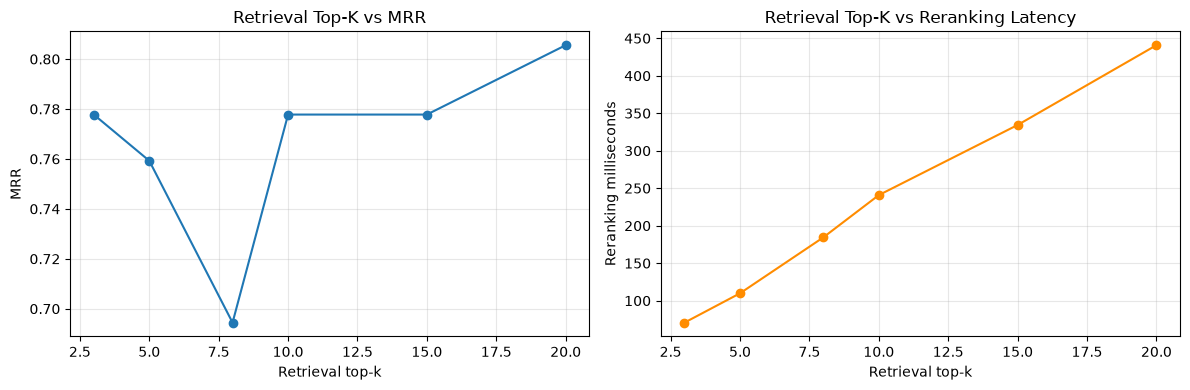

In [24]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(
    top_k_results_df["retrieval_top_k"],
    top_k_results_df["mrr"],
    marker="o",
)
axes[0].set_title("Retrieval Top-K vs MRR")
axes[0].set_xlabel("Retrieval top-k")
axes[0].set_ylabel("MRR")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    top_k_results_df["retrieval_top_k"],
    top_k_results_df["rerank_ms"],
    marker="o",
    color="darkorange",
)
axes[1].set_title("Retrieval Top-K vs Reranking Latency")
axes[1].set_xlabel("Retrieval top-k")
axes[1].set_ylabel("Reranking milliseconds")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
best_mrr_row = top_k_results_df.loc[top_k_results_df["mrr"].idxmax()]
best_recall_row = top_k_results_df.loc[top_k_results_df["page_recall_at_5"].idxmax()]
lowest_latency_row = top_k_results_df.loc[top_k_results_df["rerank_ms"].idxmin()]

print("TOP-K INTERPRETATION")
print(
    f"Best MRR: Top-K={int(best_mrr_row['retrieval_top_k'])}, "
    f"MRR={best_mrr_row['mrr']:.3f}"
)
print(
    f"Best Page Recall@5: Top-K={int(best_recall_row['retrieval_top_k'])}, "
    f"Recall={best_recall_row['page_recall_at_5']:.3f}"
)
print(
    f"Lowest reranking latency: Top-K={int(lowest_latency_row['retrieval_top_k'])}, "
    f"Latency={lowest_latency_row['rerank_ms']:.2f} ms"
)

promising_ids = {
    f"topk-{int(best_mrr_row['retrieval_top_k'])}",
    f"topk-{int(lowest_latency_row['retrieval_top_k'])}",
    reference_top_k_id,
}
print("\nPromising configurations to investigate next:")
for experiment_id in sorted(promising_ids):
    row = top_k_results_df[
        top_k_results_df["experiment_id"] == experiment_id
    ].iloc[0]
    print(
        f"Top-K={int(row['retrieval_top_k'])}: "
        f"MRR={row['mrr']:.3f}, "
        f"Page Recall@5={row['page_recall_at_5']:.3f}, "
        f"rerank={row['rerank_ms']:.2f} ms"
    )

print(
    "\nRecommendation for the next experiment: keep the selected 600/100 chunking "
    "and compare reranker-enabled versus reranker-disabled retrieval using the "
    "same promising top-k candidates. Do not treat this top-k sweep as a global optimum."
)

TOP-K INTERPRETATION
Best MRR: Top-K=20, MRR=0.806
Best Page Recall@5: Top-K=20, Recall=1.000
Lowest reranking latency: Top-K=3, Latency=70.71 ms

Promising configurations to investigate next:
Top-K=10: MRR=0.778, Page Recall@5=0.889, rerank=240.82 ms
Top-K=20: MRR=0.806, Page Recall@5=1.000, rerank=440.79 ms
Top-K=3: MRR=0.778, Page Recall@5=0.889, rerank=70.71 ms

Recommendation for the next experiment: keep the selected 600/100 chunking and compare reranker-enabled versus reranker-disabled retrieval using the same promising top-k candidates. Do not treat this top-k sweep as a global optimum.


## 18. Reranker ON vs OFF

This experiment fixes chunking at 600/100 and evaluates the same Top-K values with the Cross-Encoder disabled and enabled. Candidate page recall is measured before reranking because a reranker can reorder retrieved candidates but cannot recover a page Qdrant never retrieved.

In [26]:
def evaluate_reranker_mode(
    experiment_store: QdrantVectorStore,
    retrieval_top_k: int,
    reranker_enabled: bool,
) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    """Evaluate one ON/OFF mode while retaining candidate and final pages."""
    per_question = []
    total_retrieval_ms = 0.0
    total_rerank_ms = 0.0

    for question_record in golden_set:
        query = question_record["question"]
        retrieval_start = time.perf_counter()
        retrieved = experiment_store.similarity_search_with_score(query, k=retrieval_top_k)
        retrieval_ms = (time.perf_counter() - retrieval_start) * 1000
        total_retrieval_ms += retrieval_ms
        candidates = [
            {"document": document, "retrieval_score": float(score)}
            for document, score in retrieved
        ]
        candidate_pages = [_page_number(result["document"]) for result in candidates]

        rerank_ms = 0.0
        if reranker_enabled:
            rerank_start = time.perf_counter()
            rerank_scores = reranker.predict([
                (query, result["document"].page_content)
                for result in candidates
            ])
            rerank_ms = (time.perf_counter() - rerank_start) * 1000
            total_rerank_ms += rerank_ms
            scored_results = [
                {**result, "reranker_score": float(score)}
                for result, score in zip(candidates, rerank_scores)
            ]
            scored_results.sort(
                key=lambda result: result["reranker_score"],
                reverse=True,
            )
        else:
            scored_results = candidates

        final_results = diversify_results(
            scored_results,
            EXPERIMENT_CONFIG["reranker_top_k"],
            EXPERIMENT_CONFIG["max_chunks_per_page"],
        )
        final_pages = [_page_number(result["document"]) for result in final_results]
        expected_pages = question_record["source_pages"]
        answerable = bool(expected_pages)
        final_recall = page_recall_at_5(final_pages, expected_pages)
        candidate_recall = bool(expected_pages) and any(
            page in expected_pages for page in candidate_pages
        )
        reciprocal_rank = 0.0
        for rank, page in enumerate(final_pages, start=1):
            if page in expected_pages:
                reciprocal_rank = 1 / rank
                break

        per_question.append({
            "question": query,
            "type": question_record["type"],
            "answerable": answerable,
            "expected_source_pages": expected_pages,
            "candidate_pages": candidate_pages,
            "retrieved_pages": final_pages,
            "candidate_page_recall": candidate_recall if answerable else None,
            "page_recall_at_5": final_recall if answerable else None,
            "mrr_contribution": reciprocal_rank if answerable else None,
            "context_chars": sum(
                len(result["document"].page_content)
                for result in final_results
            ),
            "final_context_chunks": len(final_results),
            "retrieval_ms": retrieval_ms,
            "rerank_ms": rerank_ms,
        })

    answerable_rows = [row for row in per_question if row["answerable"]]
    metrics = {
        "number_of_chunks": len(top_k_chunks),
        "candidate_page_recall": sum(row["candidate_page_recall"] for row in answerable_rows) / len(answerable_rows),
        "page_recall_at_5": sum(row["page_recall_at_5"] for row in answerable_rows) / len(answerable_rows),
        "mrr": sum(row["mrr_contribution"] for row in answerable_rows) / len(answerable_rows),
        "retrieval_ms": total_retrieval_ms / len(per_question),
        "rerank_ms": total_rerank_ms / len(per_question),
        "total_ms": (total_retrieval_ms + total_rerank_ms) / len(per_question),
        "context_chars": sum(row["context_chars"] for row in per_question) / len(per_question),
        "final_context_chunks": sum(row["final_context_chunks"] for row in per_question) / len(per_question),
    }
    return metrics, per_question

In [27]:
reranker_values = [False, True]
reranker_top_k_values = [3, 10, 20]
reranker_fixed_chunk_size = 600
reranker_fixed_chunk_overlap = 100

reranker_eval_chunks = build_experiment_chunks(
    reranker_fixed_chunk_size,
    reranker_fixed_chunk_overlap,
)
r_eval_client, r_eval_store = build_memory_store(reranker_eval_chunks)
reranker_on_off_records = []
try:
    for reranker_enabled in reranker_values:
        for retrieval_top_k in reranker_top_k_values:
            run_config = {
                **EXPERIMENT_CONFIG,
                "chunk_size": reranker_fixed_chunk_size,
                "chunk_overlap": reranker_fixed_chunk_overlap,
                "retrieval_top_k": retrieval_top_k,
                "reranker_enabled": reranker_enabled,
                "reranker_top_k": EXPERIMENT_CONFIG["reranker_top_k"],
                "max_chunks_per_page": EXPERIMENT_CONFIG["max_chunks_per_page"],
            }
            metrics, details = evaluate_reranker_mode(
                r_eval_store,
                retrieval_top_k,
                reranker_enabled,
            )
            mode_name = "on" if reranker_enabled else "off"
            experiment_id = f"reranker-{mode_name}-topk-{retrieval_top_k}"
            record = {
                "experiment_id": experiment_id,
                "experiment_type": "reranker_on_off",
                "parameter_changed": "reranker_enabled",
                "configuration": {
                    **run_config,
                    "experiment_type": "reranker_on_off",
                },
                "metrics": metrics,
                "latency": {
                    "retrieval_ms": metrics["retrieval_ms"],
                    "rerank_ms": metrics["rerank_ms"],
                    "total_ms": metrics["total_ms"],
                },
                "notes": "600/100 chunking; one isolated index reused across all six runs.",
            }
            EXPERIMENT_RESULTS.append(record)
            EXPERIMENT_DETAILS[experiment_id] = details
            reranker_on_off_records.append(record)
finally:
    r_eval_client.close()

reranker_on_off_rows = []
for record in reranker_on_off_records:
    reranker_on_off_rows.append({
        "experiment_id": record["experiment_id"],
        "experiment_type": record["experiment_type"],
        "chunk_size": reranker_fixed_chunk_size,
        "chunk_overlap": reranker_fixed_chunk_overlap,
        "retrieval_top_k": record["configuration"]["retrieval_top_k"],
        "reranker_enabled": record["configuration"]["reranker_enabled"],
        "reranker_top_k": record["configuration"]["reranker_top_k"],
        **record["metrics"],
    })

reranker_on_off_results_df = pd.DataFrame(reranker_on_off_rows).sort_values(
    ["retrieval_top_k", "reranker_enabled"]
)
reranker_on_off_results_df[[
    "reranker_enabled",
    "retrieval_top_k",
    "candidate_page_recall",
    "page_recall_at_5",
    "mrr",
    "retrieval_ms",
    "rerank_ms",
    "total_ms",
    "context_chars",
    "final_context_chunks",
]]

,reranker_enabled,retrieval_top_k,candidate_page_recall,page_recall_at_5,mrr,retrieval_ms,rerank_ms,total_ms,context_chars,final_context_chunks
0,False,3,0.888889,0.888889,0.777778,15.58687,0.00000,15.58687,1523.3,3.0
3,True,3,0.888889,0.888889,0.777778,14.71170,65.08361,79.79531,1523.3,3.0
1,False,10,0.888889,0.888889,0.777778,14.27193,0.00000,14.27193,2554.0,5.0
4,True,10,0.888889,0.888889,0.777778,14.47159,215.63202,230.10361,2484.6,5.0
2,False,20,1.000000,0.888889,0.777778,14.43122,0.00000,14.43122,2554.0,5.0
5,True,20,1.000000,1.000000,0.805556,16.11339,445.92529,462.03868,2532.0,5.0


In [28]:
def _first_expected_rank(pages: list[int | None], expected_pages: list[int]) -> int | None:
    for rank, page in enumerate(pages, start=1):
        if page in expected_pages:
            return rank
    return None


comparison_rows = []
reranker_failure_rows = []
for retrieval_top_k in reranker_top_k_values:
    off_id = f"reranker-off-topk-{retrieval_top_k}"
    on_id = f"reranker-on-topk-{retrieval_top_k}"
    off_record = next(record for record in reranker_on_off_records if record["experiment_id"] == off_id)
    on_record = next(record for record in reranker_on_off_records if record["experiment_id"] == on_id)
    off_metrics = off_record["metrics"]
    on_metrics = on_record["metrics"]
    comparison_rows.append({
        "retrieval_top_k": retrieval_top_k,
        "off_page_recall_at_5": off_metrics["page_recall_at_5"],
        "on_page_recall_at_5": on_metrics["page_recall_at_5"],
        "recall_change": on_metrics["page_recall_at_5"] - off_metrics["page_recall_at_5"],
        "off_mrr": off_metrics["mrr"],
        "on_mrr": on_metrics["mrr"],
        "mrr_change": on_metrics["mrr"] - off_metrics["mrr"],
        "mrr_relative_change_pct": (
            (on_metrics["mrr"] - off_metrics["mrr"]) / off_metrics["mrr"] * 100
            if off_metrics["mrr"] else None
        ),
        "off_total_ms": off_metrics["total_ms"],
        "on_total_ms": on_metrics["total_ms"],
        "latency_cost_ms": on_metrics["total_ms"] - off_metrics["total_ms"],
        "off_context_chars": off_metrics["context_chars"],
        "on_context_chars": on_metrics["context_chars"],
    })

    off_details = EXPERIMENT_DETAILS[off_id]
    on_details = EXPERIMENT_DETAILS[on_id]
    for off_row, on_row in zip(off_details, on_details):
        expected_pages = off_row["expected_source_pages"]
        if not expected_pages:
            continue
        off_rank = _first_expected_rank(off_row["retrieved_pages"], expected_pages)
        on_rank = _first_expected_rank(on_row["retrieved_pages"], expected_pages)
        candidate_rank = _first_expected_rank(off_row["candidate_pages"], expected_pages)
        if off_rank != on_rank:
            if off_rank is None and on_rank is not None:
                interpretation = "Reranking brought a relevant page into the final context."
            elif on_rank is None:
                interpretation = "Reranking pushed the relevant page out of the final context."
            elif on_rank < off_rank:
                interpretation = "Reranking moved the relevant page higher."
            else:
                interpretation = "Reranking moved the relevant page lower."
            reranker_failure_rows.append({
                "retrieval_top_k": retrieval_top_k,
                "question": off_row["question"],
                "candidate_rank": candidate_rank,
                "off_rank": off_rank,
                "on_rank": on_rank,
                "expected_pages": expected_pages,
                "interpretation": interpretation,
            })

reranker_comparison_df = pd.DataFrame(comparison_rows)
reranker_failure_analysis_df = pd.DataFrame(reranker_failure_rows)
print("RERANKER ON VS OFF COMPARISON")
reranker_comparison_df

RERANKER ON VS OFF COMPARISON


,retrieval_top_k,off_page_recall_at_5,on_page_recall_at_5,recall_change,off_mrr,on_mrr,mrr_change,mrr_relative_change_pct,off_total_ms,on_total_ms,latency_cost_ms,off_context_chars,on_context_chars
0,3,0.888889,0.888889,0.000000,0.777778,0.777778,0.000000,0.000000,15.58687,79.79531,64.20844,1523.3,1523.3
1,10,0.888889,0.888889,0.000000,0.777778,0.777778,0.000000,0.000000,14.27193,230.10361,215.83168,2554.0,2484.6
2,20,0.888889,1.000000,0.111111,0.777778,0.805556,0.027778,3.571429,14.43122,462.03868,447.60746,2554.0,2532.0


In [29]:
print("\nReranker rank changes:")
if reranker_failure_analysis_df.empty:
    print("No final-rank changes were observed between OFF and ON configurations.")
else:
    display(reranker_failure_analysis_df)

reranker_on_off_results_df.to_csv(
    PROJECT_ROOT / "reranker_on_off_experiment_results.csv",
    index=False,
)
print(
    f"Reranker ON/OFF experiment log exported to "
    f"{PROJECT_ROOT / 'reranker_on_off_experiment_results.csv'}"
)


Reranker rank changes:


,retrieval_top_k,question,candidate_rank,off_rank,on_rank,expected_pages,interpretation
0,3,"What technologies are listed for Project 1, Do...",1,1.0,2,[1],Reranking moved the relevant page lower.
1,3,What retrieval stages are proposed before the ...,2,2.0,1,[1],Reranking moved the relevant page higher.
2,10,What retrieval stages are proposed before the ...,2,2.0,1,[1],Reranking moved the relevant page higher.
3,10,Why does the roadmap suggest hybrid search?,1,1.0,2,[2],Reranking moved the relevant page lower.
4,20,What retrieval stages are proposed before the ...,2,2.0,1,[1],Reranking moved the relevant page higher.
5,20,What observability technologies are proposed f...,20,NaN,4,[2],Reranking brought a relevant page into the fin...
6,20,Why does the roadmap suggest hybrid search?,1,1.0,2,[2],Reranking moved the relevant page lower.


Reranker ON/OFF experiment log exported to c:\Users\Shashwat\OneDrive\Desktop\DocuMind\reranker_on_off_experiment_results.csv


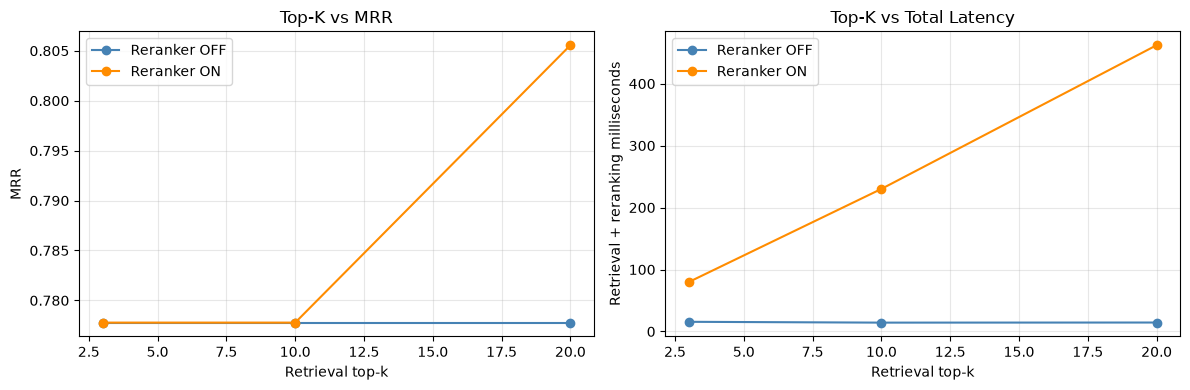

In [30]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
for reranker_enabled, label, color in [
    (False, "Reranker OFF", "steelblue"),
    (True, "Reranker ON", "darkorange"),
]:
    rows = reranker_on_off_results_df[
        reranker_on_off_results_df["reranker_enabled"] == reranker_enabled
    ].sort_values("retrieval_top_k")
    axes[0].plot(
        rows["retrieval_top_k"],
        rows["mrr"],
        marker="o",
        label=label,
        color=color,
    )
    axes[1].plot(
        rows["retrieval_top_k"],
        rows["total_ms"],
        marker="o",
        label=label,
        color=color,
    )

axes[0].set_title("Top-K vs MRR")
axes[0].set_xlabel("Retrieval top-k")
axes[0].set_ylabel("MRR")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_title("Top-K vs Total Latency")
axes[1].set_xlabel("Retrieval top-k")
axes[1].set_ylabel("Retrieval + reranking milliseconds")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
best_on = reranker_on_off_results_df[
    reranker_on_off_results_df["reranker_enabled"]
].sort_values(["mrr", "page_recall_at_5"], ascending=False).iloc[0]
best_off = reranker_on_off_results_df[
    ~reranker_on_off_results_df["reranker_enabled"]
].sort_values(["mrr", "page_recall_at_5"], ascending=False).iloc[0]

print("RERANKER VALUE ANALYSIS")
print(
    f"Best configuration with reranker: Top-K={int(best_on['retrieval_top_k'])}, "
    f"Recall={best_on['page_recall_at_5']:.3f}, MRR={best_on['mrr']:.3f}, "
    f"total latency={best_on['total_ms']:.2f} ms"
)
print(
    f"Best configuration without reranker: Top-K={int(best_off['retrieval_top_k'])}, "
    f"Recall={best_off['page_recall_at_5']:.3f}, MRR={best_off['mrr']:.3f}, "
    f"total latency={best_off['total_ms']:.2f} ms"
)

for _, row in reranker_comparison_df.iterrows():
    print(
        f"Top-K={int(row['retrieval_top_k'])}: "
        f"MRR {row['off_mrr']:.3f} -> {row['on_mrr']:.3f} "
        f"({row['mrr_change']:+.3f}, {row['mrr_relative_change_pct']:+.1f}%), "
        f"Recall {row['off_page_recall_at_5']:.3f} -> {row['on_page_recall_at_5']:.3f}, "
        f"latency cost +{row['latency_cost_ms']:.2f} ms"
    )

recall_changed = not (reranker_comparison_df["recall_change"] == 0).all()
print(
    "\nCandidate coverage note: reranking cannot recover a page absent from the "
    "initial Qdrant candidates. Candidate recall is measured separately from final Page Recall@5."
)
print(
    "Reranker decision: "
    + (
        "it changes final retrieval quality; weigh the measured gain against latency."
        if recall_changed or (reranker_comparison_df["mrr_change"] != 0).any()
        else "no measured quality change; its latency cost is not justified by this set."
    )
)
print(
    "Next experiment: keep 600/100 and compare page diversification limits, "
    "using the most informative top-k values from this matrix."
)

RERANKER VALUE ANALYSIS
Best configuration with reranker: Top-K=20, Recall=1.000, MRR=0.806, total latency=462.04 ms
Best configuration without reranker: Top-K=3, Recall=0.889, MRR=0.778, total latency=15.59 ms
Top-K=3: MRR 0.778 -> 0.778 (+0.000, +0.0%), Recall 0.889 -> 0.889, latency cost +64.21 ms
Top-K=10: MRR 0.778 -> 0.778 (+0.000, +0.0%), Recall 0.889 -> 0.889, latency cost +215.83 ms
Top-K=20: MRR 0.778 -> 0.806 (+0.028, +3.6%), Recall 0.889 -> 1.000, latency cost +447.61 ms

Candidate coverage note: reranking cannot recover a page absent from the initial Qdrant candidates. Candidate recall is measured separately from final Page Recall@5.
Reranker decision: it changes final retrieval quality; weigh the measured gain against latency.
Next experiment: keep 600/100 and compare page diversification limits, using the most informative top-k values from this matrix.
